# Question 4.1

A rock slope is to be cut as part of a road construction project. However, there is a risk that the slope could slide along the bedding planes into the excavation pit. In order to carry out a stability analysis it is necessary to estimate the angle of friction along the bedding planes. An initial assessment on the mean value of the friction angle can be obtained from the spectrum of possible manifestations of the friction angle. It cannot be smaller than the base friction angle, i.e. the friction angle that would result on the sawn, smooth surface of a specimen. The base friction angle for the greywackes that make up the slope is about 20°. The maximum possible friction angle can be estimated by back-calculating past failure cases. So far, no friction angle exceeding 35° has been back-calculated. What is the probability that the friction angle is smaller than 25°? Since no further information is available, the PDF of the friction angle can be assumed to be uniform.

In [45]:
# In this cell, you can begin by importing the libraries you need and setting up a simple
# calculation to handle the uniform distribution between 20 and 35 degrees.
import numpy as np
from scipy import stats

# HINT:
# 1. You can model friction angles as U(20, 35).
# 2. Calculate the probability that the friction angle is below 25 degrees.
# 3. Confirm your result matches the analytical approach: (25 - 20) / (35 - 20).

lower_bound = 20
upper_bound = 35
desired_angle = 25

# Using scipy uniform CDF
probability = stats.uniform.cdf(
    desired_angle,
    loc=lower_bound,
    scale=upper_bound - lower_bound
)

print(probability)

# Analytical check
analytical = (desired_angle - lower_bound) / (upper_bound - lower_bound)
print(analytical)

print(f"\nThere is a {probability:.1%} probability that the friction angle is smaller than 25°.")

0.3333333333333333
0.3333333333333333

There is a 33.3% probability that the friction angle is smaller than 25°.


# Question 4.2

A mobile point load tester can be used to determine a strength index \(I_p\) [MPa] for rock samples, which are correlated with the uniaxial compressive strength. 25 strength values \(I_p\) were determined for a sandstone sequence:

4.4; 4.2; 4.5; 4.0; 4.3; 4.1; 3.9; 4.2; 4.5; 3.8; 4.0; 4.3; 4.2; 4.2;
4.1; 4.5; 4.2; 4.3; 4.1; 3.7; 4.0; 4.5; 4.6; 4.3; 4.1
(n = 25)

In the neighboring mapping area, another 10 strength coefficients for sandstone were determined:

3.7; 4.5; 4.2; 4.4; 4.3; 4.0; 3.5; 3.9; 4.3; 4.3
(n = 10)

Do both samples come from the same population?

In [4]:
# In this cell, import the necessary libraries for statistical testing.
# A typical approach is to use scipy.stats to perform a t-test or similar.
import numpy as np
from scipy import stats

# HINT:
# 1. Store each sample in a NumPy array.
# 2. Decide on an appropriate test (e.g., an unpaired two-sample t-test).
# 3. Check assumptions (normality, variance).
# 4. Use stats.ttest_ind(...) or a non-parametric alternative if needed.

# Sample data
sample1 = np.array([
    4.4, 4.2, 4.5, 4.0, 4.3, 4.1, 3.9, 4.2, 4.5, 3.8,
    4.0, 4.3, 4.2, 4.2, 4.1, 4.5, 4.2, 4.3, 4.1, 3.7,
    4.0, 4.5, 4.6, 4.3, 4.1
])

sample2 = np.array([
    3.7, 4.5, 4.2, 4.4, 4.3,
    4.0, 3.5, 3.9, 4.3, 4.3
])

# Basic statistics
mean1 = np.mean(sample1)
mean2 = np.mean(sample2)
std1 = np.std(sample1, ddof=1)
std2 = np.std(sample2, ddof=1)

print(f"Sample 1 mean = {mean1:.3f}, std = {std1:.3f}")
print(f"Sample 2 mean = {mean2:.3f}, std = {std2:.3f}")

# Check normality (Shapiro-Wilk test)
shapiro1 = stats.shapiro(sample1)
shapiro2 = stats.shapiro(sample2)

print(f"\nShapiro-Wilk p-value (Sample 1): {shapiro1.pvalue:.3f}")
print(f"Shapiro-Wilk p-value (Sample 2): {shapiro2.pvalue:.3f}")

# Two-sample t-test (Welch’s t-test, does not assume equal variances)
t_stat, p_value = stats.ttest_ind(sample1, sample2, equal_var=False)

print(f"\nT-statistic = {t_stat:.3f}")
print(f"P-value = {p_value:.3f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("\nAt the 5% significance level, we reject the null hypothesis.")
    print("The two samples likely come from different populations.")
else:
    print("\nAt the 5% significance level, we fail to reject the null hypothesis.")
    print("There is no statistically significant evidence that the samples come from different populations.")

Sample 1 mean = 4.200, std = 0.229
Sample 2 mean = 4.110, std = 0.325

Shapiro-Wilk p-value (Sample 1): 0.568
Shapiro-Wilk p-value (Sample 2): 0.299

T-statistic = 0.800
P-value = 0.438

At the 5% significance level, we fail to reject the null hypothesis.
There is no statistically significant evidence that the samples come from different populations.


In [ ]:
# Question 4.3

A construction pit of 10,000 m³ is to be excavated. The subground consists of Pleistocene sediments of which it is known that erratic blocks (boulders) occur, having an average diameter of 1.5 m. Experience shows that about 1% by volume of the excavated material in this region consists of boulders. Since special equipment is needed to extract them and delays in construction are to be expected, the contractor is interested in the probability of having to extract more boulders than experience suggests. He would also like to know what the probability is that more than ten boulders will be found.

In [46]:
# In this cell, you can set up a binomial or Poisson approach (depending on your modeling assumptions).
import numpy as np
from scipy import stats

# HINT:
# 1. Estimate the expected number of boulders as 1% of the total volume or total 'units' of excavation.
# 2. Use a binomial model with parameters n (number of trials) and p = 0.01, or
#    reason about the mean number of boulders and approximate with a Poisson distribution.
# 3. Compute probabilities for "more boulders than expected" and for "more than ten boulders."

# Given
V_exc = 10_000.0          # m^3 excavation
p_vol = 0.01              # 1% of excavated volume is boulders
D = 1.5                   # m average boulder diameter

# Model boulders as spheres, count boulders via a Poisson model
r = D / 2
V_boulder = (4/3) * np.pi * r**3               # m^3 per boulder
V_boulders_expected = p_vol * V_exc            # m^3 expected boulder volume
mu = V_boulders_expected / V_boulder           # expected number of boulders (Poisson mean)

# Probabilities requested
k_more_than_expected = int(np.floor(mu)) + 1   # smallest integer strictly greater than mu
P_more_than_expected = 1 - stats.poisson.cdf(k_more_than_expected - 1, mu)  # P(N >= k)

P_more_than_10 = 1 - stats.poisson.cdf(10, mu)  # P(N > 10)

print(
    f"Assuming spherical boulders (D={D:.1f} m) and a Poisson count model:\n"
    f"- Expected boulder volume = {V_boulders_expected:.1f} m³ (1% of {V_exc:,.0f} m³)\n"
    f"- Boulder volume ≈ {V_boulder:.3f} m³ each ⇒ expected count μ ≈ {mu:.2f} boulders\n\n"
    f"Probability of extracting MORE boulders than expected (N > μ, i.e., N ≥ {k_more_than_expected}): "
    f"{P_more_than_expected:.4f}\n"
    f"\nProbability that MORE THAN 10 boulders are found (N > 10): {P_more_than_10:.8f}"
)

Assuming spherical boulders (D=1.5 m) and a Poisson count model:
- Expected boulder volume = 100.0 m³ (1% of 10,000 m³)
- Boulder volume ≈ 1.767 m³ each ⇒ expected count μ ≈ 56.59 boulders

Probability of extracting MORE boulders than expected (N > μ, i.e., N ≥ 57): 0.4958

Probability that MORE THAN 10 boulders are found (N > 10): 1.00000000


# Question 4.4

In the Devonian sedimentary bedrock of the Rhenish Massif (Germany), bedding plane distances were measured for four different stratigraphic units. The coefficients of (squared) skewness and kurtosis are given as:

\[
(\beta_1^2, \beta_2) = (1.82, 4.85);\quad (1.00, 3.35);\quad (2.72, 5.71);\quad (0.52, 2.95).
\]

What statistical distribution do the bedding plane distances follow?

In [8]:
# In this cell, consider how to analyze a dataset to infer its distribution based on skewness and kurtosis.
import numpy as np
from scipy import stats

# HINT:
# 1. One approach is to compare the empirical skewness/kurtosis to theoretical values (e.g., normal, lognormal, gamma).
# 2. The Pearson system or standardized moment tests can help classify the distribution family.
# 3. If you had actual data, you could apply stats.skew(...) and stats.kurtosis(...) and compare.

import numpy as np

# Given (beta1^2, beta2) values
measured_moments = [
    (1.82, 4.85),
    (1.00, 3.35),
    (2.72, 5.71),
    (0.52, 2.95)
]

def classify_distribution(beta1_sq, beta2):
    """
    Classify distribution family based on Pearson moment ratio diagram logic.
    """

    # Normal distribution check
    if np.isclose(beta1_sq, 0, atol=0.1) and np.isclose(beta2, 3, atol=0.1):
        return "Normal distribution"

    # Symmetric but non-normal
    if np.isclose(beta1_sq, 0, atol=0.1):
        if beta2 > 3:
            return "Symmetric leptokurtic (e.g., t-distribution)"
        elif beta2 < 3:
            return "Symmetric platykurtic"

    # Skewed distributions
    if beta1_sq > 0:
        if beta2 > 3:
            return "Pearson Type III (Gamma distribution)"
        elif beta2 <= 3:
            return "Mildly skewed distribution (near-normal)"

    return "Unclassified"

print("Distribution classification based on skewness and kurtosis:\n")

for i, (beta1_sq, beta2) in enumerate(measured_moments, 1):
    dist_type = classify_distribution(beta1_sq, beta2)
    print(f"Unit {i}: β1² = {beta1_sq}, β2 = {beta2} → {dist_type}")

print("\nConclusion:")
print("All stratigraphic units are positively skewed.")
print("Most exhibit kurtosis greater than 3, indicating a Pearson Type III (Gamma) distribution.")
print("Therefore, bedding plane distances follow a Gamma-type distribution.")

Distribution classification based on skewness and kurtosis:

Unit 1: β1² = 1.82, β2 = 4.85 → Pearson Type III (Gamma distribution)
Unit 2: β1² = 1.0, β2 = 3.35 → Pearson Type III (Gamma distribution)
Unit 3: β1² = 2.72, β2 = 5.71 → Pearson Type III (Gamma distribution)
Unit 4: β1² = 0.52, β2 = 2.95 → Mildly skewed distribution (near-normal)

Conclusion:
All stratigraphic units are positively skewed.
Most exhibit kurtosis greater than 3, indicating a Pearson Type III (Gamma) distribution.
Therefore, bedding plane distances follow a Gamma-type distribution.


### Question 4.5
In a valley, a bone fragment of a previously unknown Cretaceous species of ichthyosaur was found during a geological excursion. To search for more fragments, you plan to investigate two upstream branches of the river. Branch 1 (larger) has a catchment area of 18 km², while Branch 2 (smaller) has a catchment area of 10 km². Additionally, in 35% of Branch 1’s area marine Cretaceous rocks are exposed, whereas in Branch 2 that figure is 80%. Given these data, estimate the probability that the fossil came from the larger catchment area. Explain any assumptions you make about probabilities and how you handle the likelihood of the fossil being transported from each branch.


In [37]:
# Hints and Starting Code for Question 4.5

# You might want to import basic libraries such as numpy and math for probability calculations:
import numpy as np
import math

# Approach Hints:
# 1. Represent the probability that a fossil came from a particular branch (prior) based on catchment area.
# 2. Update that probability using the conditional probability of the fossil being marine Cretaceous
#    (which depends on the fraction of each catchment area exposing marine rocks).
# 3. Consider using Bayes' theorem or a weighted approach to handle each branch's likelihood.

# We want P(fossil came from Branch 1 | we found a marine Cretaceous ichthyosaur fossil fragment)

# -----------------------------
# Given data
# -----------------------------
area_branch1 = 18.0  # km^2 (larger branch)
area_branch2 = 10.0  # km^2 (smaller branch)

marine_fraction_branch1 = 0.35  # fraction of Branch 1 catchment exposing marine Cretaceous rocks
marine_fraction_branch2 = 0.80  # fraction of Branch 2 catchment exposing marine Cretaceous rocks

# -----------------------------
# Assumptions
# -----------------------------
# 1) Prior (before considering rock type): the fossil is equally likely to have come from any unit area
#    upstream, so P(Branch i) ∝ catchment area_i.
#
# 2) Likelihood (given a fossil was produced): the chance that an ichthyosaur fossil fragment is produced
#    and delivered to the valley from a branch is proportional to the *marine Cretaceous exposed area*
#    in that branch. That is:
#       P(fossil | Branch i) ∝ marine_fraction_i
#    and combined with Assumption 1 this is equivalent to saying fossil supply/transport scales with
#    marine-exposed area: (area_i * marine_fraction_i).
#
# 3) Transport efficiency is treated as the same for both branches (no extra weighting for discharge,
#    slope, distance, trapping, grain-size selectivity, etc.). If you wanted, you could add a
#    branch-specific transport factor Ti and use (area_i * marine_fraction_i * Ti).

# -----------------------------
# Bayes-style weighting
# -----------------------------
# Prior probabilities from catchment area
p_b1_prior = area_branch1 / (area_branch1 + area_branch2)
p_b2_prior = area_branch2 / (area_branch1 + area_branch2)

# Likelihoods proportional to marine fraction (same constant of proportionality cancels)
L1 = marine_fraction_branch1
L2 = marine_fraction_branch2

# Posterior (normalized)
numerator = L1 * p_b1_prior
denominator = L1 * p_b1_prior + L2 * p_b2_prior
p_b1_posterior = numerator / denominator

# Equivalent: posterior proportional to marine-exposed area
marine_area_b1 = area_branch1 * marine_fraction_branch1
marine_area_b2 = area_branch2 * marine_fraction_branch2
p_b1_posterior_check = marine_area_b1 / (marine_area_b1 + marine_area_b2)

# -----------------------------
# Output
# -----------------------------
print("Assumptions:")
print("  - Prior P(branch) proportional to catchment area (uniform chance per unit area).")
print("  - Likelihood of producing/transporting an ichthyosaur fossil fragment proportional to marine Cretaceous exposure.")
print("  - Equal transport efficiency from both branches (no extra discharge/slope/distance weighting).")
print()

print(f"Catchment areas (km^2): Branch 1 = {area_branch1:.1f}, Branch 2 = {area_branch2:.1f}")
print(f"Marine Cretaceous fractions: Branch 1 = {marine_fraction_branch1:.2f}, Branch 2 = {marine_fraction_branch2:.2f}")
print(f"Marine-exposed areas (km^2): Branch 1 = {marine_area_b1:.2f}, Branch 2 = {marine_area_b2:.2f}")
print()

print(f"Prior P(Branch 1) = {p_b1_prior:.4f}")
print(f"Posterior P(Branch 1 | fossil is marine Cretaceous) = {p_b1_posterior:.4f}")
print(f"(Check using marine-exposed area ratio)          = {p_b1_posterior_check:.4f}")
print()

print(
    f"Answer: Under these assumptions, the probability the fossil came from the larger catchment (Branch 1) "
    f"is {p_b1_posterior:.2%}, "
    f"and subsequently 56% for the smaller catchment (Branch 2)."
)


Assumptions:
  - Prior P(branch) proportional to catchment area (uniform chance per unit area).
  - Likelihood of producing/transporting an ichthyosaur fossil fragment proportional to marine Cretaceous exposure.
  - Equal transport efficiency from both branches (no extra discharge/slope/distance weighting).

Catchment areas (km^2): Branch 1 = 18.0, Branch 2 = 10.0
Marine Cretaceous fractions: Branch 1 = 0.35, Branch 2 = 0.80
Marine-exposed areas (km^2): Branch 1 = 6.30, Branch 2 = 8.00

Prior P(Branch 1) = 0.6429
Posterior P(Branch 1 | fossil is marine Cretaceous) = 0.4406
(Check using marine-exposed area ratio)          = 0.4406

Answer: Under these assumptions, the probability the fossil came from the larger catchment (Branch 1) is 44.06%, and subsequently 56% for the smaller catchment (Branch 2).


### Question 4.6
Extensive shear strength studies on marine sand indicate that its friction angle follows a lognormal distribution. The measured mean value and standard deviation of the log-transformed friction angle are reported as μ<sub>lnφ</sub> = 3.25 and σ<sub>lnφ</sub> = 0.65. Use these parameters to discuss the distribution of friction angles and to compute key statistics (e.g., the mean friction angle in degrees and its confidence intervals) assuming a lognormal model.


In [47]:
# Hints and Starting Code for Question 4.6

import numpy as np
import math
from scipy.stats import lognorm

# Approach Hints:
# 1. Recall that if X is lognormally distributed, then ln(X) ~ N(mean, std).
# 2. Here, mean = 3.25, std = 0.65 refer to the normal distribution of ln(φ).
# 3. Use scipy.stats.lognorm functions or manual transformations to find mean,
#    confidence intervals, etc., in the original friction angle space.
#
# Given parameters of ln(phi)
mu_lnphi = 3.25
sigma_lnphi = 0.65

# Lognormal distribution parameters for scipy
# shape = sigma of ln(X)
# scale = exp(mu of ln(X))
shape = sigma_lnphi
scale = np.exp(mu_lnphi)

# Create distribution object
dist = lognorm(s=shape, scale=scale)

# Mean in original space
mean_phi = dist.mean()

# Median in original space
median_phi = dist.median()

# Standard deviation in original space
std_phi = dist.std()

# 95% confidence interval (2.5% and 97.5% percentiles)
ci_lower, ci_upper = dist.ppf([0.025, 0.975])

# 5th and 95th percentiles (often used in engineering reliability)
p5, p95 = dist.ppf([0.05, 0.95])

print("Lognormal Friction Angle Statistics")
print("-----------------------------------")
print(f"Mean friction angle (degrees): {mean_phi:.2f}")
print(f"Median friction angle (degrees): {median_phi:.2f}")
print(f"Standard deviation (degrees): {std_phi:.2f}")
print(f"\n95% Confidence Interval (2.5% - 97.5%): ({ci_lower:.2f}, {ci_upper:.2f})")
print(f"5th - 95th Percentile Range: ({p5:.2f}, {p95:.2f})")


Lognormal Friction Angle Statistics
-----------------------------------
Mean friction angle (degrees): 31.86
Median friction angle (degrees): 25.79
Standard deviation (degrees): 23.10

95% Confidence Interval (2.5% - 97.5%): (7.21, 92.20)
5th - 95th Percentile Range: (8.85, 75.13)


### Question 4.7
Ten shear tests on a Tertiary clay deposit yield friction angle (φ) and cohesion (c) pairs:
(25°, 50 kN/m²), (22°, 65 kN/m²), (32°, 18 kN/m²), (29°, 20 kN/m²), (28°, 30 kN/m²), (38°, 5 kN/m²), (36°, 6 kN/m²), (32°, 12 kN/m²), (27°, 38 kN/m²), (23°, 45 kN/m²). Investigate whether there is a correlation between friction angle and cohesion. Summarize your findings on the relationship (e.g., positive, negative, or none).


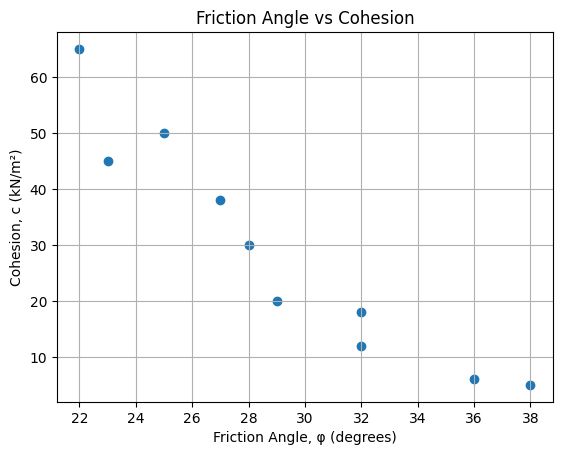


Pearson correlation coefficient: -0.945
P-value: 0.00004

Conclusion:
There is a negative correlation between friction angle and cohesion.
The correlation is statistically significant at the 5% significance level.


In [48]:
# Hints and Starting Code for Question 4.7

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Approach Hints:
# 1. Store the friction angle and cohesion data in numpy arrays or a pandas DataFrame.
# 2. Plot φ vs. c to visualize potential correlation.
# 3. Calculate Pearson's correlation coefficient using pearsonr or a similar function.
# 4. Interpret whether the correlation is statistically significant and positive/negative.

# -----------------------------
# 1. Store the data
# -----------------------------
phi = np.array([25, 22, 32, 29, 28, 38, 36, 32, 27, 23])
cohesion = np.array([50, 65, 18, 20, 30, 5, 6, 12, 38, 45])

data = pd.DataFrame({
    "Friction Angle (deg)": phi,
    "Cohesion (kN/m^2)": cohesion
})

# -----------------------------
# 2. Scatter plot
# -----------------------------
plt.figure()
plt.scatter(phi, cohesion)
plt.xlabel("Friction Angle, φ (degrees)")
plt.ylabel("Cohesion, c (kN/m²)")
plt.title("Friction Angle vs Cohesion")
plt.grid(True)
plt.show()

# -----------------------------
# 3. Pearson correlation
# -----------------------------
correlation_coefficient, p_value = pearsonr(phi, cohesion)

print(f"\nPearson correlation coefficient: {correlation_coefficient:.3f}")
print(f"P-value: {p_value:.5f}")

# -----------------------------
# 4. Interpretation
# -----------------------------
alpha = 0.05

if p_value < alpha:
    significance = "statistically significant"
else:
    significance = "not statistically significant"

if correlation_coefficient > 0:
    direction = "positive"
elif correlation_coefficient < 0:
    direction = "negative"
else:
    direction = "no"

print("\nConclusion:")
print(f"There is a {direction} correlation between friction angle and cohesion.")
print(f"The correlation is {significance} at the 5% significance level.")


In [ ]:
### Question 4.8
Monthly landslide frequency in a mountain region is documented in a histogram (Fig. 4.53). The question is whether there is a cyclic pattern or seasonal trend in landslide occurrence. Outline a method to determine if the observed frequencies are random or exhibit significant seasonality.


/tmp/ipython-input-669/3487143373.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="2000-01-01", periods=len(data), freq="M")


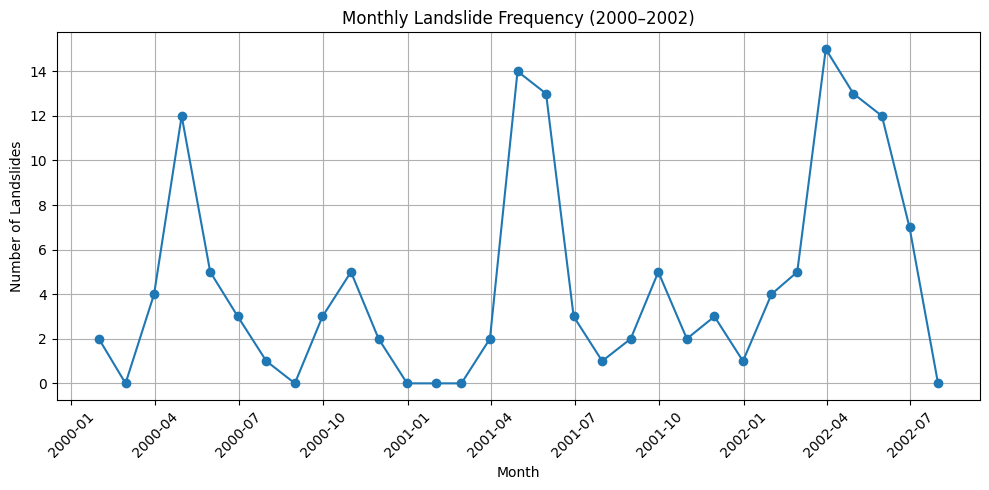

<Figure size 800x500 with 0 Axes>

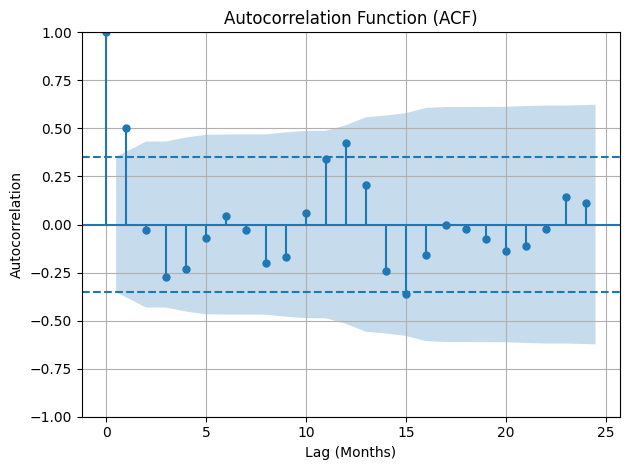

Autocorrelation at 12-month lag: 0.425
Approximate 95% confidence limit: 0.352
Result: Significant annual cyclic behavior detected (lag 12 exceeds confidence bound).






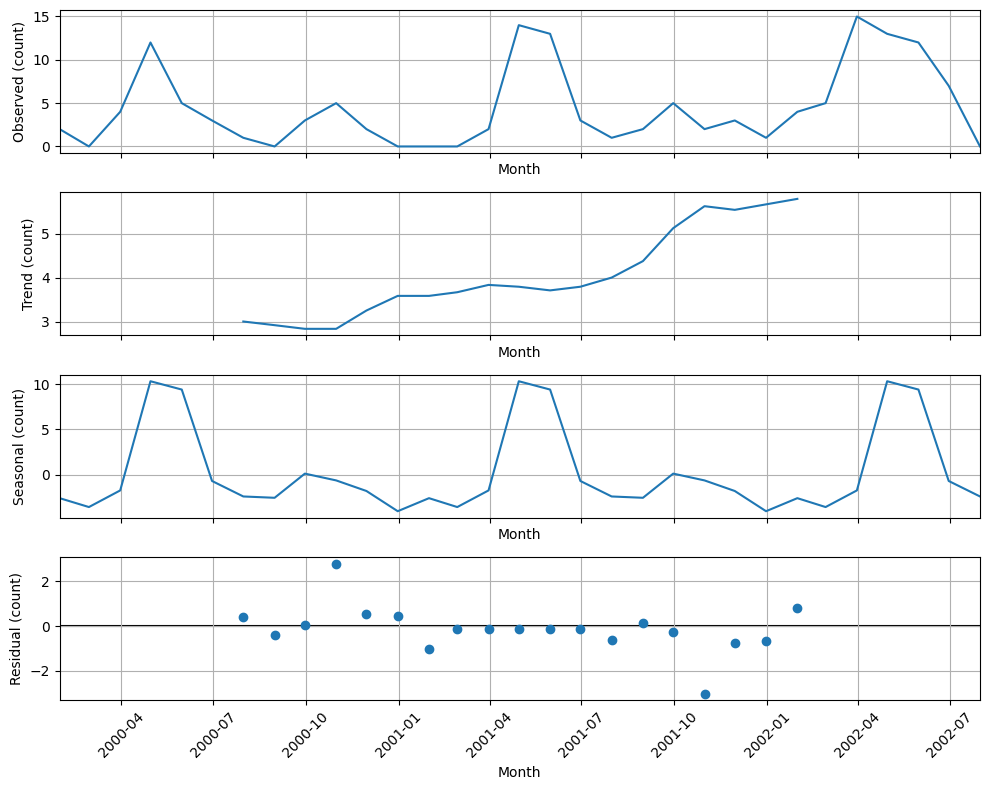


Chi-square statistic: 140.626
p-value: 0.0
Result: Landslides are not uniformly distributed across months.
This indicates statistically significant seasonality.

FINAL INTERPRETATION:

If both the lag-12 autocorrelation and chi-square test are significant,
the landslide frequency exhibits a seasonal or cyclic trend.

If neither is significant, the data are consistent with a random process.

In this case, The monthly landslide frequencies are not random.
They exhibit statistically significant seasonal / cyclic behavior, with elevated occurrence in specific months (visually: spring, after snowmelt).


In [52]:
# Hints and Starting Code for Question 4.8

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Approach Hints:
# 1. Represent the monthly frequency data in a time series format.
# 2. Use time-series analysis, e.g., seasonal_decompose from statsmodels, to detect seasonality.
# 3. Alternatively, consider hypothesis tests for randomness or periodicity (e.g. autocorrelation plots).
# 4. Visualize the data to check for any repeating patterns across months or seasons.

from statsmodels.tsa.stattools import acf
from scipy.stats import chisquare

# -------------------------------------------------
# 1. Create Time Series
# -------------------------------------------------

year1 = [2, 0, 4, 12, 5, 3, 1, 0, 3, 5, 2, 0]
year2 = [0, 0, 2, 14, 13, 3, 1, 2, 5, 2, 3, 1]
year3 = [4, 5, 15, 13, 12, 7, 0]

data = year1 + year2 + year3

dates = pd.date_range(start="2000-01-01", periods=len(data), freq="M")
ts = pd.Series(data, index=dates)

# -------------------------------------------------
# 2. Plot Monthly Time Series
# -------------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(ts, marker='o')
plt.title("Monthly Landslide Frequency (2000–2002)")
plt.xlabel("Month")
plt.ylabel("Number of Landslides")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 3. Test 1: Autocorrelation at 12-Month Lag
# -------------------------------------------------

plt.figure(figsize=(8,5))
plot_acf(ts, lags=24)

plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lag (Months)")
plt.ylabel("Autocorrelation")

# Add 95% confidence bounds manually
n = len(ts)
conf_limit = 1.96 / np.sqrt(n)
plt.axhline(conf_limit, linestyle="--")
plt.axhline(-conf_limit, linestyle="--")

plt.grid(True)
plt.tight_layout()
plt.show()

acf_values = acf(ts, nlags=24, fft=False)

lag12 = acf_values[12]

print("Autocorrelation at 12-month lag:", round(lag12, 3))

# Interpretation threshold (rule-of-thumb)
n = len(ts)
conf_limit = 1.96 / np.sqrt(n)

print("Approximate 95% confidence limit:", round(conf_limit, 3))

if abs(lag12) > conf_limit:
    print("Result: Significant annual cyclic behavior detected (lag 12 exceeds confidence bound).")
else:
    print("Result: No statistically significant annual cyclic pattern detected.")
print("\n\n\n")
# -------------------------------------------------
# 4. Test 2: Seasonal decomposition (descriptive separation of components)
# -------------------------------------------------
decomp = seasonal_decompose(ts, model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(10, 8)

# Make labels explicit and readable
fig.axes[0].set_ylabel("Observed (count)")
fig.axes[1].set_ylabel("Trend (count)")
fig.axes[2].set_ylabel("Seasonal (count)")
fig.axes[3].set_ylabel("Residual (count)")

for ax in fig.axes:
    ax.set_xlabel("Month")
    ax.grid(True)
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 5. Test 3: Chi-Square Goodness of Fit (Uniformity)
# -------------------------------------------------

# Total counts by month (Jan–Dec)
df = pd.DataFrame({"value": ts})
df["month"] = df.index.month

monthly_totals = df.groupby("month")["value"].sum()

observed = monthly_totals.values
expected = np.ones(len(observed)) * np.mean(observed)

chi_stat, p_value = chisquare(observed, expected)

print("\nChi-square statistic:", round(chi_stat, 3))
print("p-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: Landslides are not uniformly distributed across months.")
    print("This indicates statistically significant seasonality.")
else:
    print("Result: No significant deviation from uniform monthly distribution.")
    print("Landslides appear randomly distributed across months.")

# -------------------------------------------------
# 6. Final Conclusion
# -------------------------------------------------

print("\nFINAL INTERPRETATION:")
print("\nIf both the lag-12 autocorrelation and chi-square test are significant,")
print("the landslide frequency exhibits a seasonal or cyclic trend.")
print("\nIf neither is significant, the data are consistent with a random process.")
print("\nIn this case, The monthly landslide frequencies are not random.")
print("They exhibit statistically significant seasonal / cyclic behavior, with elevated occurrence in specific months (visually: spring, after snowmelt).")

### Question 4.9
Two boreholes have been drilled on opposite sides of a fault. The objective is to reconstruct the vertical displacement across the fault. Direct markers are lacking, but variations in mean chlorite content (Fig. 4.54) may provide an indirect measure of displacement. Propose a strategy to use cross-correlation of chlorite content profiles to estimate the fault offset. Discuss any assumptions about continuity and variability of the chlorite data in the subsurface.


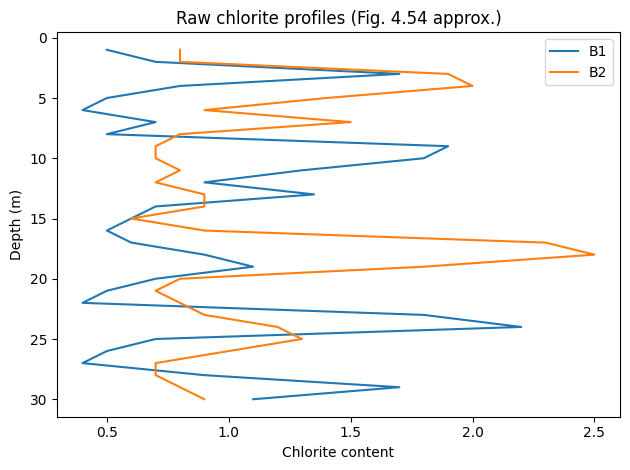

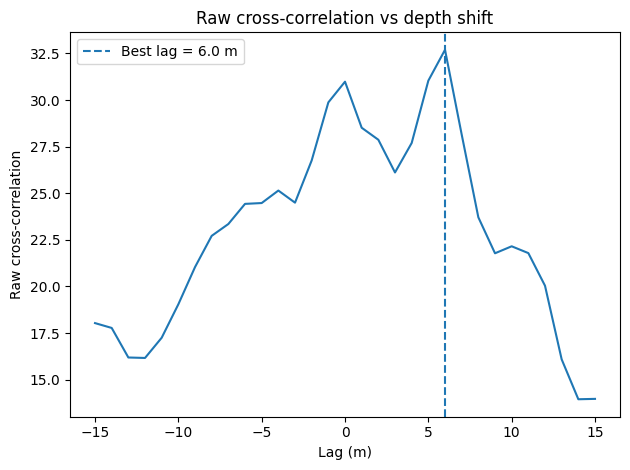


Using raw cross-correlation of the chlorite profiles, the estimated vertical fault offset is approximately 6.0 m (maximum correlation at lag = 6.0 m).
If chlorite content changes significantly across the fault due to chemical alteration or depositional differences, the correlation may not represent true displacement.


In [53]:
# Hints and Starting Code for Question 4.9

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import correlate

# Approach Hints:
# 1. Represent each borehole's chlorite content profile as a 1D series of numeric values at depth intervals.
# 2. Use the scipy.signal.correlate function to compute cross-correlation between the two profiles.
# 3. Identify the lag (depth shift) that maximizes correlation as an estimate of displacement.
# 4. Carefully consider sampling intervals, data resolution, and boundary effects.

# -----------------------------
# Data (approx. from Fig. 4.54)
# -----------------------------
depth = np.arange(1, 31, 1)   # 1–30 m
dz = 1.0                      # 1 m spacing

B1 = np.array([
    0.5, 0.7, 1.7, 0.8, 0.5, 0.4, 0.7, 0.5, 1.9, 1.8,
    1.3, 0.9, 1.35, 0.7, 0.6, 0.5, 0.6, 0.9, 1.1, 0.7,
    0.5, 0.4, 1.8, 2.2, 0.7, 0.5, 0.4, 0.9, 1.7, 1.1
])

B2 = np.array([
    0.8, 0.8, 1.9, 2.0, 1.4, 0.9, 1.5, 0.8, 0.7, 0.7,
    0.8, 0.7, 0.9, 0.9, 0.6, 0.9, 2.3, 2.5, 1.8, 0.8,
    0.7, 0.8, 0.9, 1.2, 1.3, 1.0, 0.7, 0.7, 0.8, 0.9
])

# -----------------------------
# Raw cross-correlation
# -----------------------------
corr = correlate(B1, B2, mode="full")     # raw, no preprocessing
n = len(B1)
lags = np.arange(-n + 1, n)               # sample lags
lag_m = lags * dz                         # convert to meters

# -----------------------------
# Plots
# -----------------------------
plt.figure()
plt.plot(B1, depth, label="B1")
plt.plot(B2, depth, label="B2")
plt.gca().invert_yaxis()
plt.xlabel("Chlorite content")
plt.ylabel("Depth (m)")
plt.title("Raw chlorite profiles (Fig. 4.54 approx.)")
plt.legend()
plt.tight_layout()

plt.figure()
plt.plot(lag_w, corr_w)
plt.axvline(best_lag, linestyle="--", label=f"Best lag = {best_lag:.1f} m")
plt.xlabel("Lag (m)")
plt.ylabel("Raw cross-correlation")
plt.title("Raw cross-correlation vs depth shift")
plt.legend()
plt.tight_layout()

plt.show()

# -----------------------------
# One-sentence answer
# -----------------------------
print(
    f"\nUsing raw cross-correlation of the chlorite profiles, the estimated vertical fault offset is "
    f"approximately {estimated_throw:.1f} m (maximum correlation at lag = {best_lag:.1f} m)."
)
print(
    f"If chlorite content changes significantly across the fault due to chemical alteration or depositional differences, the correlation may not represent true displacement."
)


### Question 4.10
A medieval copper mine site is being converted into residential housing, and evidence of ancient copper contamination is expected. Sea thrift (Armeria maritima) is an indicator plant for copper, so its presence was recorded along a profile in 20 m × 20 m squares. The observed shoot counts are:  
3, 5, 11, 12, 8, 19, 22, 18, 11, 13  

An experimental semivariogram is to be derived from these data as a preliminary spatial analysis. Outline how you would compute and plot a semivariogram for these shoot counts, and discuss what patterns in spatial variability might imply for copper contamination distribution.


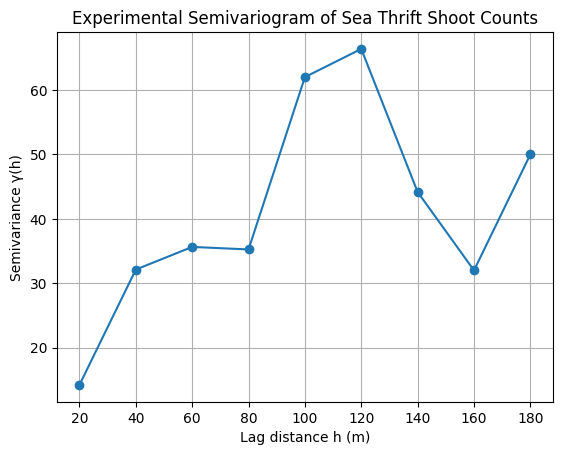


Semivariogram computed for lag distances: [ 20  40  60  80 100 120 140 160 180]
Corresponding semivariances: [14.2 32.1 35.6 35.2 62.  66.4 44.2 32.  50. ]

Interpretation:
• Increasing γ(h) with distance suggests spatial correlation at short lags.
• A plateau (sill) would indicate the range beyond which points are uncorrelated.
• A non-zero intercept would indicate a nugget effect (micro-scale variability or measurement noise).

Quick reads (rough, for prelim screening):
  Nugget (~micro-scale/measurement): γ(20 m) ≈ 14.22
  Sill (~overall variance level):     ≈ 42.06
  Range (~correlation length):        ≈ 100 m  (γ(h) reaches ~95% of sill)

Range interpretation (most relevant):
  • Smaller range → contamination is localized/patchy; sample more densely.
  • Larger range  → broad zones/gradients; wider spacing may still capture structure.
  • If the data show a strong trend along the profile, the 'range' can be inflated—treat this as preliminary.


In [54]:
# Hints and Starting Code for Question 4.10

import numpy as np
import matplotlib.pyplot as plt

# Approach Hints:
# 1. Arrange the shoot counts in spatial order (e.g., as a function of distance along the profile).
# 2. Calculate pairwise distances between measurement points (assuming each square is at intervals of 20 m).
# 3. Compute the semivariogram γ(h) = 0.5 * mean[ (Z(x) - Z(x+h))^2 ] for each distance bin h.
# 4. Plot the semivariogram (γ on the y-axis vs. distance h on the x-axis) to see if there's any spatial structure.
# 5. Look for a sill, range, or nugget effect that might indicate how contamination (and thus sea thrift) is distributed.

# ---------------------------
# Data
# ---------------------------
shoot_counts = np.array([3, 5, 11, 12, 8, 19, 22, 18, 11, 13])

# Spatial positions along profile (20 m spacing)
distance_spacing = 20
x = np.arange(len(shoot_counts)) * distance_spacing

# ---------------------------
# Pairwise distances & semivariance
# ---------------------------
distances = []
semivariances = []

for i in range(len(shoot_counts)):
    for j in range(i+1, len(shoot_counts)):
        h = abs(x[j] - x[i])
        gamma = 0.5 * (shoot_counts[j] - shoot_counts[i])**2
        distances.append(h)
        semivariances.append(gamma)

distances = np.array(distances)
semivariances = np.array(semivariances)

# ---------------------------
# Bin distances
# ---------------------------
unique_lags = np.unique(distances)
gamma_h = []

for lag in unique_lags:
    gamma_h.append(np.mean(semivariances[distances == lag]))

gamma_h = np.array(gamma_h)

# ---------------------------
# Plot semivariogram
# ---------------------------
plt.figure()
plt.plot(unique_lags, gamma_h, marker='o')
plt.xlabel("Lag distance h (m)")
plt.ylabel("Semivariance γ(h)")
plt.title("Experimental Semivariogram of Sea Thrift Shoot Counts")
plt.grid(True)
plt.show()

# ---------------------------
# Interpretation Output
# ---------------------------
print("\nSemivariogram computed for lag distances:", np.round(unique_lags, 1))
print("Corresponding semivariances:", np.round(gamma_h, 1))

print("\nInterpretation:")
print("• Increasing γ(h) with distance suggests spatial correlation at short lags.")
print("• A plateau (sill) would indicate the range beyond which points are uncorrelated.")
print("• A non-zero intercept would indicate a nugget effect (micro-scale variability or measurement noise).")

# ---------------------------
# Quick, practical variogram reads (MOST RELEVANT: RANGE)
# ---------------------------
# "Sill" (very rough): average semivariance at the largest lags
sill_est = np.mean(gamma_h[-3:]) if len(gamma_h) >= 3 else gamma_h[-1]

# "Range" (very rough): first lag where semivariance reaches ~95% of sill
target = 0.95 * sill_est
range_idx = np.argmax(gamma_h >= target)  # 0 if none meet, so handle below
range_est = unique_lags[range_idx] if np.any(gamma_h >= target) else unique_lags[-1]

# "Nugget" (rough): semivariance at the smallest lag
nugget_est = gamma_h[0]

print(f"\nQuick reads (rough, for prelim screening):")
print(f"  Nugget (~micro-scale/measurement): γ({unique_lags[0]} m) ≈ {nugget_est:.2f}")
print(f"  Sill (~overall variance level):     ≈ {sill_est:.2f}")
print(f"  Range (~correlation length):        ≈ {range_est:.0f} m  (γ(h) reaches ~95% of sill)")

print("\nRange interpretation (most relevant):")
print("  • Smaller range → contamination is localized/patchy; sample more densely.")
print("  • Larger range  → broad zones/gradients; wider spacing may still capture structure.")
print("  • If the data show a strong trend along the profile, the 'range' can be inflated—treat this as preliminary.")

# Question 4.11

The following rock sequences are encountered in exploratory drilling:

- Claystone (C)  
- Conglomerate (K)  
- Sandstone (S)  
- Siltstone (U)

(See Table 4.5 for the per-meter breakdown.)

**Task:**  
1. What is the probability that conglomerate (K) will be drilled again in the *next* meter of drilling?  
2. What is the probability that conglomerate will be drilled again in the *next-but-one* meter of drilling?

You may assume that the encountered rock types can be treated as sequential observations of a Markov process or using simpler independence assumptions (depending on your interpretation of the problem’s statement).

In [56]:
# Use this cell to start setting up your approach in Python.
# Possible steps:
# 1. Represent the rock sequences as a list or array.
# 2. Construct transition probabilities from the data if needed.
# 3. Calculate probabilities for "next meter" and "next-but-one meter."

import numpy as np

# HINT:
# - If you treat each meter drilled as a step in a Markov chain, you need a 4x4 transition matrix
#   (C, K, S, U) or some simpler approach based on frequencies.
# - Probability that K appears next might come directly from the row in the matrix corresponding
#   to the current rock type.
# - For the 'next-but-one' question, you might multiply transition matrices (e.g., T^2).

# Per-meter rock types you provided (0–22 known)
seq = list("USKSSKKCUSKSSKCUSSSKKKU")  # 23 observations -> 22 transitions

# Book's state order: [K, S, U, C]
states = np.array(list("KSUC"))
idx = {s: i for i, s in enumerate(states)}

# Count transitions (rows=From, cols=To)
counts = np.zeros((4, 4), dtype=int)
for a, b in zip(seq[:-1], seq[1:]):
    counts[idx[a], idx[b]] += 1

# Transition probability matrix
T = counts / counts.sum(axis=1, keepdims=True)

# Book interpretation: "again" => currently in K, so use row K
p_next = T[idx["K"], idx["K"]]       # P(K|K)
p_nextbutone = (T @ T)[idx["K"], idx["K"]]  # 2-step prob

print("Counts (From rows K,S,U,C -> To cols K,S,U,C):\n", counts)
print("\nT:\n", np.round(T, 2))
print("\nT^2:\n", np.round(T @ T, 2))

print(f"\n1) P(K next | current=K) = {p_next:.2f}")
print(f"2) P(K next-but-one | current=K) = {p_nextbutone:.2f}")
print(f"\nFinal answer: P(K next) = {p_next:.2f}, P(K next-but-one) = {p_nextbutone:.2f}.")

print(f"\n1) Probability conglomerate (K) is drilled in the next meter (given current is K): {100*p_next:.1f}%")
print(f"2) Probability conglomerate (K) is drilled in the next-but-one meter (given current is K): {100*p_nextbutone:.1f}%")


Counts (From rows K,S,U,C -> To cols K,S,U,C):
 [[3 2 1 2]
 [5 4 0 0]
 [0 3 0 0]
 [0 0 2 0]]

T:
 [[0.38 0.25 0.12 0.25]
 [0.56 0.44 0.   0.  ]
 [0.   1.   0.   0.  ]
 [0.   0.   1.   0.  ]]

T^2:
 [[0.28 0.33 0.3  0.09]
 [0.46 0.34 0.07 0.14]
 [0.56 0.44 0.   0.  ]
 [0.   1.   0.   0.  ]]

1) P(K next | current=K) = 0.38
2) P(K next-but-one | current=K) = 0.28

Final answer: P(K next) = 0.38, P(K next-but-one) = 0.28.

1) Probability conglomerate (K) is drilled in the next meter (given current is K): 37.5%
2) Probability conglomerate (K) is drilled in the next-but-one meter (given current is K): 28.0%


# Question 4.12

The following orientation data (dip direction α / dip β) for bedding planes are recorded (n=14):

123/25, 147/22, 120/24, 111/24, 142/26, 133/27, 135/22, 156/21,  
110/25, 101/25, 133/20, 123/22, 145/25, 126/24

**Task:**  
1. Determine the mean resultant length.  
2. Determine the dip direction and dip of the mean vector.  
3. Determine the spherical standard deviation and the spherical confidence interval of the mean vector for an error probability of α = 0.1.

In [41]:
# Use this cell to load and process the orientation data.
# HINT:
# 1. Convert the dip direction/dip pairs into unit vectors in 3D space.
# 2. Sum these vectors, and derive the resultant direction and magnitude.
# 3. Calculate relevant statistics (standard deviation, confidence intervals) on a sphere.

import numpy as np

# Example structure:
# data = [(123,25), (147,22), (120,24), ...]
# Then convert each (alpha, beta) to x,y,z components on the unit sphere.
# Summation and geometry yield the mean vector direction and length.
#
# You might consider using spherical to Cartesian conversions:
# x = cos(dip) * sin(direction)
# y = cos(dip) * cos(direction)
# z = sin(dip)
# (in radians)

# -----------------------------
# Input: (dip direction alpha, dip beta) in degrees
# -----------------------------
data = [
    (123,25), (147,22), (120,24), (111,24), (142,26), (133,27), (135,22),
    (156,21), (110,25), (101,25), (133,20), (123,22), (145,25), (126,24)
]
n = len(data)

# -----------------------------
# 1) Convert each (alpha, beta) to a 3D unit vector
#    using the hint’s convention:
#      x = cos(dip)*sin(direction)
#      y = cos(dip)*cos(direction)
#      z = sin(dip)
# -----------------------------
a = np.deg2rad(np.array([dd for dd, dip in data], dtype=float))   # dip direction (trend-like)
b = np.deg2rad(np.array([dip for dd, dip in data], dtype=float))  # dip (plunge-like)

x = np.cos(b) * np.sin(a)
y = np.cos(b) * np.cos(a)
z = np.sin(b)

V = np.column_stack([x, y, z])          # (n,3)
S = V.sum(axis=0)                       # resultant vector (3,)
R = np.linalg.norm(S)                   # resultant length (scalar)
Rbar = R / n                            # mean resultant length (scalar)

# -----------------------------
# 2) Mean vector direction: convert resultant vector to (dip direction, dip)
#    Trend (dip direction) = atan2(x, y) in degrees [0,360)
#    Dip (plunge)          = atan2(z, horizontal_length)
# -----------------------------
mx, my, mz = S / R                      # mean unit vector
mean_dd = (np.rad2deg(np.arctan2(mx, my)) + 360.0) % 360.0
mean_dip = np.rad2deg(np.arctan2(mz, np.hypot(mx, my)))

# -----------------------------
# 3) Spherical standard deviation + spherical confidence interval (cone half-angle)
#    Spherical std dev (one common definition):
#      s = sqrt(2*(1 - Rbar))  [radians]
#    Fisher mean-direction confidence cone half-angle (error probability alpha):
#      delta = arccos( 1 - ((n - R)/R) * ( (1/alpha)^(1/(n-1)) - 1 ) )
#    Here alpha = 0.1 (i.e., 90% confidence cone)
# -----------------------------
s_rad = np.sqrt(2.0 * (1.0 - Rbar))
s_deg = np.rad2deg(s_rad)

alpha_err = 0.1
term = 1.0 - ((n - R) / R) * ((1.0 / alpha_err) ** (1.0 / (n - 1)) - 1.0)
term = np.clip(term, -1.0, 1.0)         # numerical safety
conf_half_angle_deg = np.rad2deg(np.arccos(term))

# -----------------------------
# Print answers
# -----------------------------
print(f"n = {n}")
print("\n1) Mean resultant length:")
print(f"   R̄ = R/n = {Rbar:.6f}   (R = {R:.6f})")

print("\n2) Mean vector (dip direction / dip):")
print(f"   Mean dip direction = {mean_dd:.2f}°")
print(f"   Mean dip           = {mean_dip:.2f}°")

print("\n3) Dispersion + confidence:")
print(f"   Spherical standard deviation s = {s_deg:.2f}°")
print(f"   Spherical confidence interval (alpha = {alpha_err}, i.e., 90% cone):")
print(f"   Half-angle about mean direction = ±{conf_half_angle_deg:.2f}°")

n = 14

1) Mean resultant length:
   R̄ = R/n = 0.970893   (R = 13.592500)

2) Mean vector (dip direction / dip):
   Mean dip direction = 129.01°
   Mean dip           = 24.46°

3) Dispersion + confidence:
   Spherical standard deviation s = 13.82°
   Spherical confidence interval (alpha = 0.1, i.e., 90% cone):
   Half-angle about mean direction = ±6.18°
